# AI Architectural Milestones

This notebook breaks down the mathematical evolution of modern AI. From the earliest perceptron to modern Transformers, almost all architectures rely on chained **Linear Transformations** (i.e. $y = Wx + b$).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display

class LinearTransform:
    def __init__(self, w, b):
        self.w = np.array(w, dtype=float)
        self.b = np.array(b, dtype=float)

    def forward(self, x):
        return np.dot(self.w, x) + self.b

### Mathematical Visualization (SymPy)

We can natively render the algebraic matrices making up the formula $Wx + b$ using SymPy's visual rendering.

In [ ]:
w_sym = sp.Matrix([[1.5, 0.5], [-0.5, 1.0]])
x_sym = sp.Matrix([2.0, 1.0])
b_sym = sp.Matrix([1.0, -1.0])

print("W matrix:")
display(w_sym)
print("x input:")
display(x_sym)
print("b bias:")
display(b_sym)
print("W * x + b Result:")
display(w_sym * x_sym + b_sym)

W matrix:


Matrix([
[ 1.5, 0.5],
[-0.5, 1.0]])

x input:


Matrix([
[2.0],
[1.0]])

b bias:


Matrix([
[ 1.0],
[-1.0]])

W * x + b Result:


Matrix([
[ 4.5],
[-1.0]])

### Geometric Intuition (Matplotlib)

**What are linear transformations good for?**
They are mathematical operations that map input vectors to new spaces. By stretching, rotating, and shifting data points, a linear transformation (like $y = Wx + b$) can project complex data into a space where it is easily understandable. Good examples include rotating an image in computer graphics, compressing features via PCA dimensionality reduction, or moving abstract word representations closer together in NLP.

**What is happening?**
The input data point is being physically moved, rotated, and stretched by the network's matrix layer.

**What are we visualizing?**
The blue arrow is our starting `x_input` vector. The red arrow shows the new transformed output vector after it has been acted upon by weight matrix $W$ and shifted by bias $b$.

**Connection to the Perceptron & AI Architectures**
How does this relate to the Perceptron? A Perceptron is simply a Linear Transformation followed by a Step Function (a threshold). The '$W$' matrix represents the learned weights, and '$b$' is the learned bias. Through training, the Perceptron adjusts $W$ and $b$ to dynamically move and rotate the input vector into a space where it can be easily classified. In the examples below, you will see how every core AI architecture—from Perceptrons to Transformers—uses this exact same geometric operation under the hood to process information.

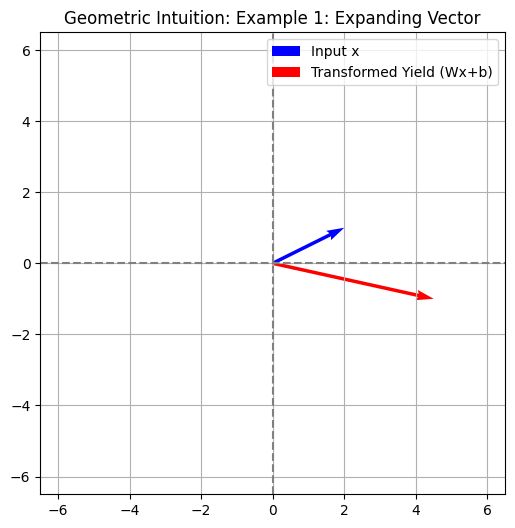

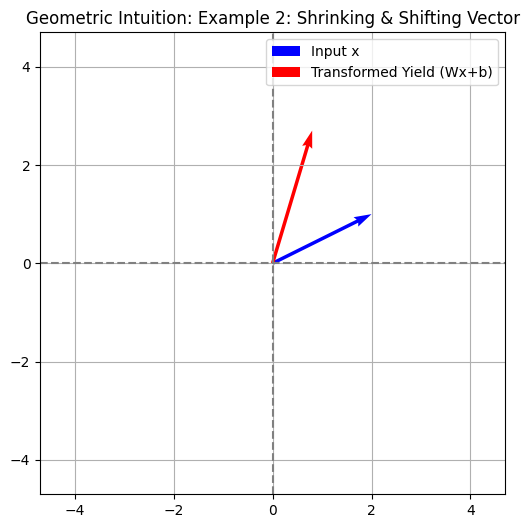

In [ ]:
class VectorVisualizer:
    def __init__(self, w_matrix=[[1.5, 0.5], [-0.5, 1.0]], b_vector=[1.0, -1.0], x_input=[2.0, 1.0], title="Example 1"):
        self.w_matrix = w_matrix
        self.b_vector = b_vector
        self.x_input = x_input
        self.title = title

    def run(self):
        w = np.array(self.w_matrix)
        b = np.array(self.b_vector)
        x = np.array(self.x_input)
        y = np.dot(w, x) + b
        
        plt.figure(figsize=(6, 6))
        plt.axhline(0, color='gray', linestyle='--')
        plt.axvline(0, color='gray', linestyle='--')
        plt.quiver(0, 0, x[0], x[1], angles='xy', scale_units='xy', scale=1, color='blue', label='Input x')
        plt.quiver(0, 0, y[0], y[1], angles='xy', scale_units='xy', scale=1, color='red', label='Transformed Yield (Wx+b)')
        
        max_limit = max(abs(np.concatenate([x, y]))) + 2
        plt.xlim(-max_limit, max_limit)
        plt.ylim(-max_limit, max_limit)
        plt.grid()
        plt.legend()
        plt.title(f'Geometric Intuition: {self.title}')
        plt.show()

# Example 1: Expanding Vector
visualizer_1 = VectorVisualizer(w_matrix=[[1.5, 0.5], [-0.5, 1.0]], b_vector=[1.0, -1.0], x_input=[2.0, 1.0], title="Example 1: Expanding Vector")
visualizer_1.run()

# Example 2: Shrinking & Shifting Vector
visualizer_2 = VectorVisualizer(w_matrix=[[0.5, -0.2], [0.1, 0.5]], b_vector=[0.0, 2.0], x_input=[2.0, 1.0], title="Example 2: Shrinking & Shifting Vector")
visualizer_2.run()

## 1. Perceptron (1958)

The **Perceptron** represents the genesis of artificial neural networks. Mathematically, it operates precisely like our standard Linear Transformation: it computes a dot product of inputs, scales them by weights, adds a bias, and passes the sum into a discrete step function (often $1$ if $z > 0$ else $0$). 

**Visual Check:** A single perceptron essentially attempts to draw a straight line (a 'decision boundary') perfectly splitting two classes of data in space.

In [ ]:
class PerceptronDemo(LinearTransform):
    def __init__(self, x, y_true, lr=0.1, epochs=10, title='Perceptron Visual Decision Boundary'):
        X_arr = np.atleast_2d(x)
        num_features = X_arr.shape[1]
        np.random.seed(42)
        w_init = np.random.randn(num_features) * 0.1
        b_init = [0.0]
        super().__init__(w=w_init, b=b_init)
        self.X = X_arr
        self.y_true = np.array(y_true)
        self.lr = lr
        self.epochs = epochs
        self.title = title

    def run(self):
        for _ in range(self.epochs):
            for i, x_i in enumerate(self.X):
                z = self.forward(x_i)
                y_pred = 1 if z >= 0 else 0
                error = self.y_true[i] - y_pred
                if error != 0:
                    self.w += self.lr * error * x_i
                    self.b += self.lr * error
                    
        colors = ['red' if y == 1 else 'blue' for y in self.y_true]
        plt.figure(figsize=(6,5))
        plt.scatter(self.X[:,0], self.X[:,1], c=colors, edgecolor='k', zorder=5)
        
        x_min, x_max = self.X[:,0].min() - 1, self.X[:,0].max() + 1
        y_min, y_max = self.X[:,1].min() - 1, self.X[:,1].max() + 1
        x1_vals = np.array([x_min, x_max])
        
        if self.w[1] != 0:
            x2_vals = (-self.w[0]*x1_vals - self.b[0]) / self.w[1]
            plt.plot(x1_vals, x2_vals, 'k--', label='Decision Boundary')
            if self.w[1] > 0:
                plt.fill_between(x1_vals, x2_vals, y_max+5, color='red', alpha=0.1)
                plt.fill_between(x1_vals, y_min-5, x2_vals, color='blue', alpha=0.1)
            else:
                plt.fill_between(x1_vals, x2_vals, y_max+5, color='blue', alpha=0.1)
                plt.fill_between(x1_vals, y_min-5, x2_vals, color='red', alpha=0.1)
        
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)
        plt.legend()
        plt.title(self.title)
        plt.show()

### Example 1: Learning the AND Logic Gate
Unlike passing explicit boundary weights, we start with random weights and use the classic Perceptron Learning Rule to train the network iteratively against 'true/false' (1/0) values.

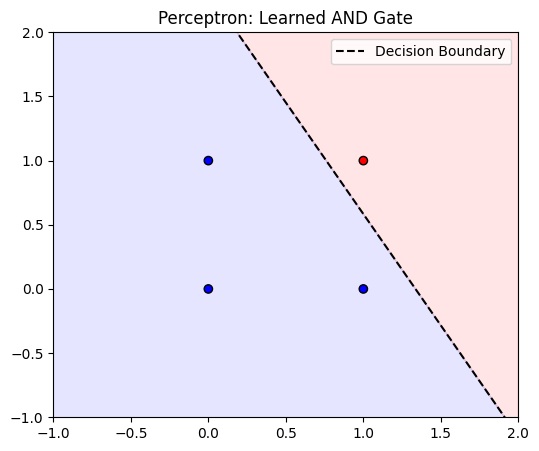

In [ ]:
X_and = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_and = np.array([0, 0, 0, 1])
perceptron_1 = PerceptronDemo(x=X_and, y_true=y_and, lr=0.1, epochs=10, title='Perceptron: Learned AND Gate')
perceptron_1.run()

### Example 2: Pass/Fail classification
Here we train the perceptron on a linearly separable physical dataset forecasting whether a student passes based on hours studied vs hours continuously slept.

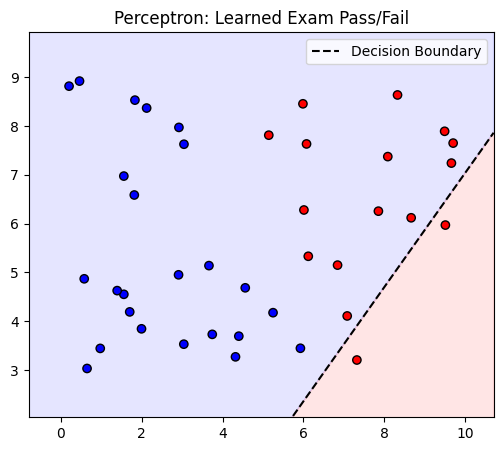

In [ ]:
np.random.seed(42)
N = 40
study_hours = np.random.uniform(0, 10, N)
sleep_hours = np.random.uniform(3, 9, N)
X_students = np.column_stack([study_hours, sleep_hours])
scores = study_hours + 0.5 * sleep_hours
y_students = np.where(scores > 8.0, 1, 0)

perceptron_2 = PerceptronDemo(x=X_students, y_true=y_students, lr=0.1, epochs=20, title='Perceptron: Learned Exam Pass/Fail')
perceptron_2.run()

Running with Learning Rate: 0.05


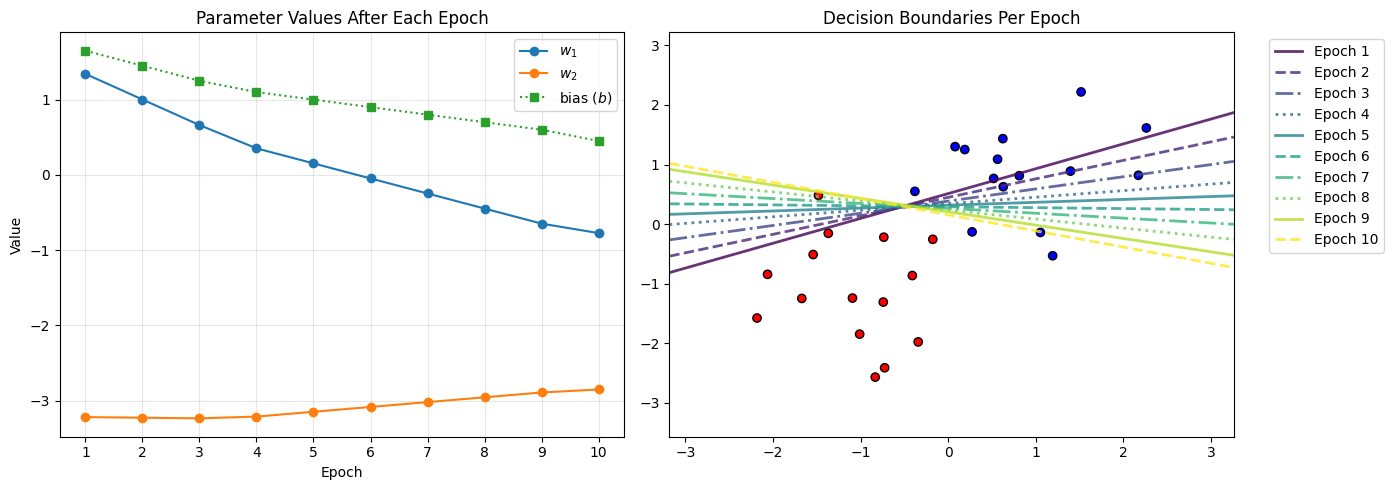

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class PerceptronDemo:
    def __init__(self, x, y_true, lr=0.1, epochs=10):
        self.X = x
        self.y_true = y_true
        self.lr = lr
        self.epochs = epochs
        # Start with intentionally 'bad' weights so we can watch it learn
        self.w = np.array([2.0, -3.0]) 
        self.b = np.array([2.0])
        
    def forward(self, x):
        return np.dot(x, self.w) + self.b[0]

class EpochWeightTracker(PerceptronDemo):
    def __init__(self, x, y_true, lr=0.1, epochs=10):
        super().__init__(x, y_true, lr, epochs)
        self.epoch_w_history = []
        self.epoch_b_history = []

    def run_with_tracking(self):
        for epoch in range(self.epochs):
            for i, x_i in enumerate(self.X):
                z = self.forward(x_i)
                y_pred = 1 if z >= 0 else 0
                error = self.y_true[i] - y_pred
                
                if error != 0:
                    self.w += self.lr * error * x_i
                    self.b += self.lr * error
            
            # Save state at the end of the epoch
            self.epoch_w_history.append(self.w.copy())
            self.epoch_b_history.append(self.b[0])
        
        self.plot_results()

    def plot_results(self):
        w_hist = np.array(self.epoch_w_history)
        b_hist = np.array(self.epoch_b_history)
        epochs = np.arange(1, self.epochs + 1)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # Plot 1: Parameter Trajectories per Epoch
        ax1.plot(epochs, w_hist[:, 0], label='$w_1$', marker='o', color='tab:blue')
        ax1.plot(epochs, w_hist[:, 1], label='$w_2$', marker='o', color='tab:orange')
        ax1.plot(epochs, b_hist, label='bias ($b$)', linestyle=':', marker='s', color='tab:green')
        ax1.set_title("Parameter Values After Each Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Value")
        ax1.set_xticks(epochs)
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Plot 2: Decision Boundaries per Epoch
        colors = ['red' if y == 1 else 'blue' for y in self.y_true]
        ax2.scatter(self.X[:,0], self.X[:,1], c=colors, edgecolor='k')
        
        # Calculate axis limits based on data
        x_min, x_max = self.X[:,0].min()-1, self.X[:,0].max()+1
        y_min, y_max = self.X[:,1].min()-1, self.X[:,1].max()+1
        x_vals = np.array([x_min, x_max])
        
        cmap = plt.get_cmap('viridis')
        line_styles = ['-', '--', '-.', ':']
        
        for i in range(self.epochs):
            w_epoch = w_hist[i]
            b_epoch = b_hist[i]
            
            if w_epoch[1] != 0:
                y_vals = (-w_epoch[0] * x_vals - b_epoch) / w_epoch[1]
                color = cmap(i / max(1, self.epochs - 1))
                style = line_styles[i % len(line_styles)]
                
                ax2.plot(x_vals, y_vals, color=color, linestyle=style, 
                         linewidth=2, label=f'Epoch {i+1}', alpha=0.8)

        ax2.set_title("Decision Boundaries Per Epoch")
        ax2.set_xlim(x_min, x_max)
        ax2.set_ylim(y_min, y_max)
        ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        plt.show()

# --- Execution ---

np.random.seed(42)

# 1. Create two clusters closer together
class_0 = np.random.randn(15, 2) * 0.8 + np.array([1, 1])
y_0 = np.zeros(15)
class_1 = np.random.randn(15, 2) * 0.8 + np.array([-1, -1])
y_1 = np.ones(15)

# 2. Combine and SHUFFLE the training data
X_dummy = np.vstack((class_0, class_1))
y_dummy = np.concatenate((y_0, y_1))

shuffle_idx = np.random.permutation(len(y_dummy))
X_dummy = X_dummy[shuffle_idx]
y_dummy = y_dummy[shuffle_idx]

# 3. Run tracking with lower learning rate to see smaller steps
print("Running with Learning Rate: 0.05")
tracker1 = EpochWeightTracker(X_dummy, y_dummy, lr=0.05, epochs=10)
tracker1.run_with_tracking()

## 2. Backpropagation (1986)

Hidden layers solved the Perceptron's non-linear limits, but training those layers mathematically was practically impossible. **Backpropagation** algorithmically calculates gradients backward utilizing the Chain Rule of calculus. It systematically tells the model how far 'off' each weight mathematically is from perfect accuracy.

**Visual Check:** Below we plot Loss over 20 iterations. Because gradients point strictly strictly 'downhill', you can visibly watch the optimization rapidly conquer the mean-squared-error penalty.

In [ ]:
class BackpropagationDemo(LinearTransform):
    def __init__(self, x, y_true, lr=0.001, epochs=50, title='Backpropagation Demo'):
        X_arr = np.atleast_2d(x)
        num_features = X_arr.shape[1]
        np.random.seed(42)
        w_init = np.random.randn(num_features) * 0.1
        b_init = 0.0
        super().__init__(w=w_init, b=b_init)
        self.x = X_arr
        self.y_true = np.array(y_true)
        self.lr = lr
        self.epochs = epochs
        self.title = title

    def run(self):
        losses = []
        N = self.x.shape[0]
        for _ in range(self.epochs):
            y_pred = self.forward(self.x.T)
            loss = 0.5 * np.mean((y_pred - self.y_true)**2)
            losses.append(loss)
            
            grad_y = (y_pred - self.y_true) / N
            grad_w = np.dot(self.x.T, grad_y)
            grad_b = np.sum(grad_y)
            
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b
            
        plt.figure(figsize=(6,4))
        plt.plot(range(1, self.epochs+1), losses, marker='o', linestyle='-', color='purple')
        plt.title(self.title)
        plt.xlabel('Epochs')
        plt.ylabel('Mean Squared Error Loss')
        plt.show()

### Example 1: Predicting House Prices
Imagine we want to predict a house price dynamically based on thousands of examples comparing rooms and age. The model initializes randomly and backprop adjusts towards the optimal targets.

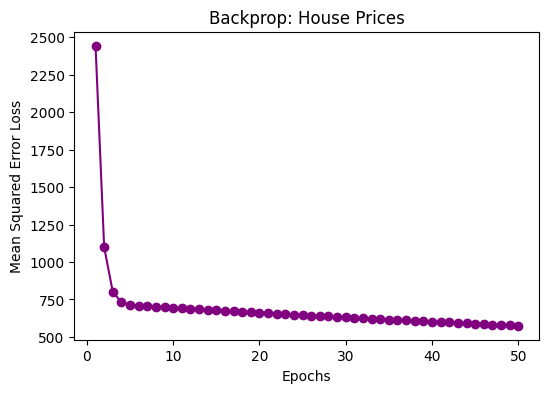

In [ ]:
np.random.seed(42)
N = 100
rooms = np.random.normal(3, 1, N)
age = np.random.uniform(1, 40, N)
X_houses = np.column_stack([rooms, age])
# True target: Price = 10 * rooms - 0.5 * age + 50
y_houses = 10.0 * rooms - 0.5 * age + 50.0 + np.random.randn(N)*2.0

backprop_1 = BackpropagationDemo(x=X_houses, y_true=y_houses, lr=0.001, epochs=50, title='Backprop: House Prices')
backprop_1.run()

### Example 2: Predicting Car Depreciation
If we have a negative value feature (e.g. depreciation with miles), backprop correctly adjusts the weights downwards.

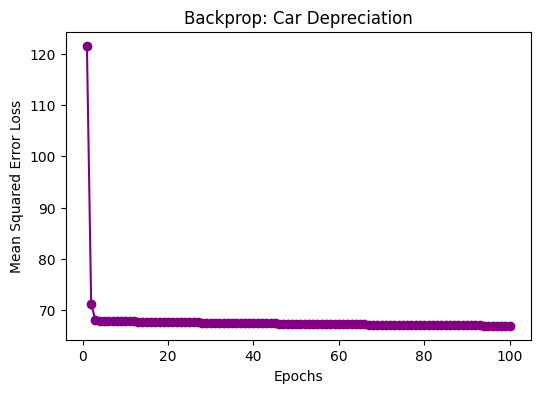

In [ ]:
age_car = np.random.uniform(0, 20, N)
miles_car = np.random.uniform(0, 150, N)
X_cars = np.column_stack([age_car, miles_car])
# True target: Price = 30 - 1 * age - 0.1 * miles
y_cars = 30.0 - 1.0 * age_car - 0.1 * miles_car + np.random.randn(N)*0.5 

backprop_2 = BackpropagationDemo(x=X_cars, y_true=y_cars, lr=0.0001, epochs=100, title='Backprop: Car Depreciation')
backprop_2.run()

## 3. CNNs / AlexNet (2012)

Instead of plugging every single pixel into a dense line of transformations, **Convolutional Neural Networks (CNNs)** scan patches dynamically using much smaller, shared 'Filters'. This captures specific spatial structures (edges, corners) globally and proved that Deep Learning scaling via GPUs could crush traditional image tasks (see: AlexNet, 2012).

**Visual Check:** We display the discrete pixel matrix being 'convolved' against a tiny 2x2 edge-detector Filter.

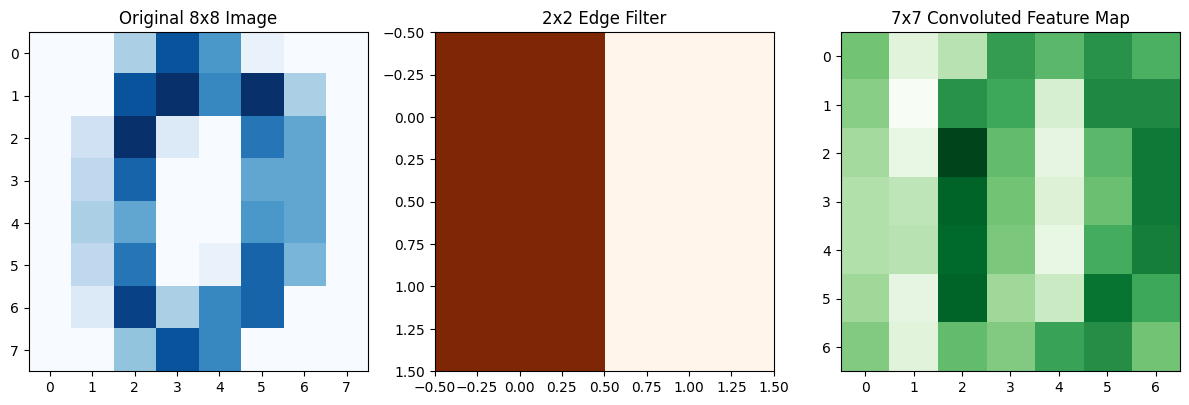

In [ ]:
class CNNDemo:
    def __init__(self):
        from sklearn.datasets import load_digits
        digits = load_digits()
        self.image = digits.images[0] / 16.0
        self.filter = np.array([
            [1, -1],
            [1, -1]
        ])

    def run(self):
        h, w = self.image.shape
        fh, fw = self.filter.shape
        output = np.zeros((h - fh + 1, w - fw + 1))
        for i in range(output.shape[0]):
            for j in range(output.shape[1]):
                patch = self.image[i:i+fh, j:j+fw]
                output[i, j] = np.sum(patch * self.filter)
                
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(self.image, cmap='Blues')
        axes[0].set_title('Original 8x8 Image')
        axes[1].imshow(self.filter, cmap='Oranges')
        axes[1].set_title('2x2 Edge Filter')
        axes[2].imshow(output, cmap='Greens')
        axes[2].set_title('7x7 Convoluted Feature Map')
        plt.tight_layout()
        plt.show()

CNNDemo().run()

## 4. RNNs / LSTMs (2014-2016)

To handle sequenced arrays (like spoken sentences), **Recurrent Neural Networks (RNNs)** were designed with literal memory banks. A hidden representation matrix calculates its new output dynamically based on BOTH the current token and what was processed dynamically in the previous tick of time.

**Visual Check:** Below we plot an unrolled time-series trajectory tracking the activations of two internal 'hidden nodes' as they ingest sequence vectors iteratively.

In [ ]:
class RNNDemo:
    def __init__(self):
        self.transform_x = LinearTransform(w=[[0.5, -0.2], [0.1, 0.8]], b=[0.0, 0.0])
        self.transform_h = LinearTransform(w=[[0.7, 0.1], [-0.1, 0.6]], b=[0.1, -0.1])
        self.sequence = [np.array([1.0, 0.0]) if i%2==0 else np.array([0.0, 1.0]) for i in range(15)]

    def run(self):
        hidden_states = []
        hidden = np.array([0.0, 0.0])
        for x_t in self.sequence:
            z = self.transform_x.forward(x_t) + self.transform_h.forward(hidden)
            hidden = np.tanh(z)
            hidden_states.append(hidden)
            
        hidden_states = np.array(hidden_states)
        plt.figure(figsize=(7,4))
        plt.plot(hidden_states[:, 0], label='Hidden Node 1', marker='s')
        plt.plot(hidden_states[:, 1], label='Hidden Node 2', marker='^')
        plt.title('RNN Hidden State Dynamics Over Time')
        plt.xlabel('Time Sequence Tick')
        plt.ylabel('Internal Activation Intensity')
        plt.grid(True)
        plt.legend()
        plt.show()

RNNDemo().run()

## 5. Transformers (2017)

**Transformers** proved RNN-style memory was a sequential gridlock bottleneck! Their breakthrough lies in mapping sequence tokens indiscriminately in parallel via 'Attention'. They evaluate every piece of an input against every other piece, calculating a massive relational proximity score grid dynamically against Query, Key, and Value components.

**Visual Check:** Below is an Attention Matrix Heatmap. Notice visually how darker cells indicate the exact tokens providing mathematical 'attention' to other contextual tokens across the sequence.

In [ ]:
class TransformerDemo:
    def __init__(self):
        self.x = np.array([
            [1.0, 0.0, 0.1], 
            [0.1, 0.9, 0.1], 
            [0.2, 0.1, 0.8], 
            [0.9, 0.2, 0.0]  
        ])
        self.q_proj = LinearTransform(w=np.eye(3) * 0.5, b=[0]*3)
        self.k_proj = LinearTransform(w=np.eye(3) * 0.5, b=[0]*3)

    def run(self):
        Q = np.array([self.q_proj.forward(row) for row in self.x])
        K = np.array([self.k_proj.forward(row) for row in self.x])
        
        scores = np.dot(Q, K.T) / np.sqrt(3)
        exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
        attn_w = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
        
        words = ["The", "cat", "sat", "down"]
        
        plt.figure(figsize=(6,5))
        plt.imshow(attn_w, cmap='magma')
        for i in range(len(words)):
            for j in range(len(words)):
                plt.text(j, i, f'{attn_w[i, j]:.2f}', ha="center", va="center", color="black" if attn_w[i,j] > 0.5 else "white")
        plt.colorbar(label='Self-Attention Relational Weight')
        plt.xticks(range(len(words)), words)
        plt.yticks(range(len(words)), words)
        plt.title('Transformer Attention Weights Heatmap')
        plt.ylabel('Token Querying Context')
        plt.xlabel('Token Being Attended To')
        plt.show()

TransformerDemo().run()